<a href="https://colab.research.google.com/github/suryap-0812/DS-Hackathon/blob/main/DS_Day01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day - 01 - Q6

In [7]:
# DAY 01 - Q6

# ==============================
# 1. LOAD & INSPECT DATASET
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

# Upload CSV in Colab first
from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["Customer_ID"].duplicated().sum())

print("\nCategorical Values:")
print("\nOccupation:")
print(df["Occupation"].value_counts(dropna=False))

print("\nAge Group:")
print(df["Age_Group"].value_counts(dropna=False))

print("\nNumerical Summary:")
display(df.describe())

Saving DS_Day01_06_Banking_Inconsistent_Dataset_250.csv to DS_Day01_06_Banking_Inconsistent_Dataset_250 (1).csv
Dataset Shape: (260, 8)

First 5 Rows:


,Customer_ID,Age_Group,Occupation,Monthly_Income,Monthly_Expenses,Savings,Credit_Card_Spending,Loan_Amount
0,CUST_031,36-45,Self-employed,89100.0,53700.0,38900.0,13700.0,73000.0
1,CUST_182,18-25,Self-employed,32800.0,29100.0,2900.0,8800.0,94000.0
2,CUST_224,26-35,Self-employed,87900.0,70100.0,18300.0,15800.0,228000.0
3,CUST_186,36-45,Self-employed,91900.0,79400.0,13800.0,9900.0,193000.0
4,CUST_212,36-45,Salaried,33500.0,26900.0,8900.0,12300.0,83000.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           260 non-null    object 
 1   Age_Group             260 non-null    object 
 2   Occupation            256 non-null    object 
 3   Monthly_Income        253 non-null    float64
 4   Monthly_Expenses      255 non-null    float64
 5   Savings               254 non-null    float64
 6   Credit_Card_Spending  260 non-null    float64
 7   Loan_Amount           260 non-null    float64
dtypes: float64(5), object(3)
memory usage: 16.4+ KB

Missing Values:
Customer_ID             0
Age_Group               0
Occupation              4
Monthly_Income          7
Monthly_Expenses        5
Savings                 6
Credit_Card_Spending    0
Loan_Amount             0
dtype: int64

Duplicate Rows: 10
Duplicate Customer IDs: 10

Categorical Values:

Occu

,Monthly_Income,Monthly_Expenses,Savings,Credit_Card_Spending,Loan_Amount
count,253.000000,255.000000,254.000000,260.000000,2.600000e+02
mean,53975.889328,35280.436368,20764.317242,8643.846154,2.600885e+05
std,22531.947594,20665.611738,15762.065244,5409.565443,2.365318e+05
min,-12000.000000,-8000.000000,-25000.000000,-3000.000000,-1.000000e+05
25%,36700.000000,21300.000000,10800.000000,4875.000000,1.040000e+05
50%,53900.000000,32400.000000,18500.000000,8000.000000,1.830000e+05
75%,69200.000000,45500.000000,27800.000000,11400.000000,3.432500e+05
max,122700.000000,179023.269896,72239.434249,29000.000000,1.500000e+06


In [8]:
# ==============================
# 2. DATA CLEANING
# ==============================

clean_df = df.copy()

# Remove duplicate customers
clean_df = clean_df.drop_duplicates(
    subset="Customer_ID",
    keep="first"
)

# Standardize Occupation
clean_df["Occupation"] = (
    clean_df["Occupation"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["Occupation"] = clean_df["Occupation"].replace({
    "salaried": "Salaried",
    "self-employed": "Self-employed",
    "self employed": "Self-employed",
    "business": "Self-employed",
    "freelancer": "Self-employed"
})

# Standardize Age Groups
clean_df["Age_Group"] = (
    clean_df["Age_Group"]
    .astype("string")
    .str.strip()
)

clean_df["Age_Group"] = clean_df["Age_Group"].replace({
    "26 - 35": "26-35",
    "36–45": "36-45",
    "46_55": "46-55"
})

# Handle missing categorical values
clean_df["Occupation"] = clean_df["Occupation"].fillna(
    clean_df["Occupation"].mode()[0]
)

# Convert invalid numerical values to NaN
numeric_cols = [
    "Monthly_Income",
    "Monthly_Expenses",
    "Savings",
    "Credit_Card_Spending",
    "Loan_Amount"
]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )

# Invalid values
clean_df.loc[clean_df["Monthly_Income"] <= 0, "Monthly_Income"] = np.nan
clean_df.loc[clean_df["Monthly_Expenses"] < 0, "Monthly_Expenses"] = np.nan
clean_df.loc[clean_df["Savings"] < 0, "Savings"] = np.nan
clean_df.loc[clean_df["Credit_Card_Spending"] < 0, "Credit_Card_Spending"] = np.nan
clean_df.loc[clean_df["Loan_Amount"] < 0, "Loan_Amount"] = np.nan

# Fill numerical missing values with median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )

# Feature engineering
clean_df["Savings_Ratio"] = (
    clean_df["Savings"] /
    clean_df["Monthly_Income"]
) * 100

clean_df["Expense_Ratio"] = (
    clean_df["Monthly_Expenses"] /
    clean_df["Monthly_Income"]
) * 100

print("Cleaned Dataset Shape:", clean_df.shape)

print("\nRemaining Missing Values:")
print(clean_df.isnull().sum())

print("\nDuplicate Customer IDs:",
      clean_df["Customer_ID"].duplicated().sum())

display(clean_df.head())

Cleaned Dataset Shape: (250, 10)

Remaining Missing Values:
Customer_ID             0
Age_Group               0
Occupation              0
Monthly_Income          0
Monthly_Expenses        0
Savings                 0
Credit_Card_Spending    0
Loan_Amount             0
Savings_Ratio           0
Expense_Ratio           0
dtype: int64

Duplicate Customer IDs: 0


,Customer_ID,Age_Group,Occupation,Monthly_Income,Monthly_Expenses,Savings,Credit_Card_Spending,Loan_Amount,Savings_Ratio,Expense_Ratio
0,CUST_031,36-45,Self-employed,89100.0,53700.0,38900.0,13700.0,73000.0,43.658810,60.269360
1,CUST_182,18-25,Self-employed,32800.0,29100.0,2900.0,8800.0,94000.0,8.841463,88.719512
2,CUST_224,26-35,Self-employed,87900.0,70100.0,18300.0,15800.0,228000.0,20.819113,79.749716
3,CUST_186,36-45,Self-employed,91900.0,79400.0,13800.0,9900.0,193000.0,15.016322,86.398259
4,CUST_212,36-45,Salaried,33500.0,26900.0,8900.0,12300.0,83000.0,26.567164,80.298507


========== DESCRIPTIVE STATISTICS ==========


,count,mean,std,min,25%,50%,75%,max
Monthly_Income,250.0,54638.400000,21466.334094,18000.000000,38250.000000,54100.000000,68975.000000,1.227000e+05
Monthly_Expenses,250.0,35682.045095,20372.357555,0.000000,22000.000000,32700.000000,45275.000000,1.790233e+05
Savings,250.0,22193.171695,13804.751055,100.000000,12850.000000,19250.000000,27551.511045,7.223943e+04
Credit_Card_Spending,250.0,8811.600000,5337.303878,0.000000,5000.000000,8000.000000,11400.000000,2.900000e+04
Loan_Amount,250.0,264136.000000,237063.823748,0.000000,104500.000000,185500.000000,347750.000000,1.500000e+06
Savings_Ratio,250.0,42.175889,21.975208,0.482315,28.409956,38.810642,52.572309,1.069444e+02
Expense_Ratio,250.0,66.202274,27.897209,0.000000,51.719946,62.073749,78.024640,2.103681e+02



Income vs Expense Correlation: 0.637


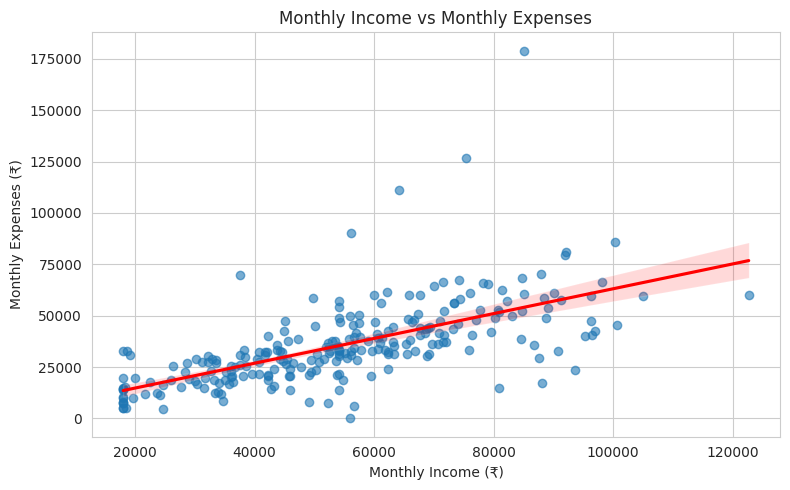


========== OCCUPATION SUMMARY ==========


,Monthly_Income,Monthly_Expenses,Savings,Credit_Card_Spending,Loan_Amount,Savings_Ratio
Occupation,,,,,,
Salaried,54557.668712,35265.340150,22234.949232,8767.484663,256996.932515,41.292966
Self-employed,54789.655172,36462.768154,22114.898838,8894.252874,277511.494253,43.830102


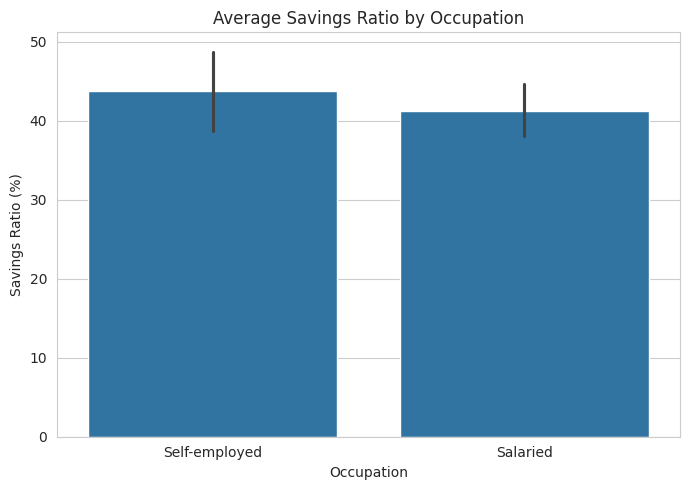

In [9]:
# ==============================
# 3. EDA + VISUALIZATIONS
# ==============================

print("========== DESCRIPTIVE STATISTICS ==========")
display(clean_df.describe().T)

# Income-Expense correlation
correlation = clean_df[
    "Monthly_Income"
].corr(
    clean_df["Monthly_Expenses"]
)

print(
    "\nIncome vs Expense Correlation:",
    round(correlation, 3)
)

# --------------------------------
# Visualization 1
# Income vs Expenses
# --------------------------------

plt.figure(figsize=(8, 5))

sns.regplot(
    data=clean_df,
    x="Monthly_Income",
    y="Monthly_Expenses",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Monthly Income vs Monthly Expenses")
plt.xlabel("Monthly Income (₹)")
plt.ylabel("Monthly Expenses (₹)")
plt.tight_layout()
plt.show()


# --------------------------------
# Visualization 2
# Savings Ratio by Occupation
# --------------------------------

occupation_summary = clean_df.groupby(
    "Occupation"
)[
    [
        "Monthly_Income",
        "Monthly_Expenses",
        "Savings",
        "Credit_Card_Spending",
        "Loan_Amount",
        "Savings_Ratio"
    ]
].mean()

print("\n========== OCCUPATION SUMMARY ==========")
display(occupation_summary)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=clean_df,
    x="Occupation",
    y="Savings_Ratio"
)

plt.title("Average Savings Ratio by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Savings Ratio (%)")
plt.tight_layout()
plt.show()

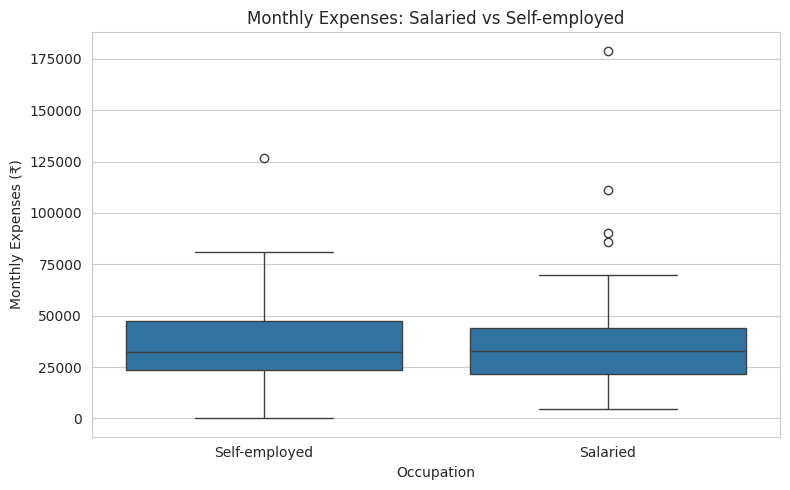

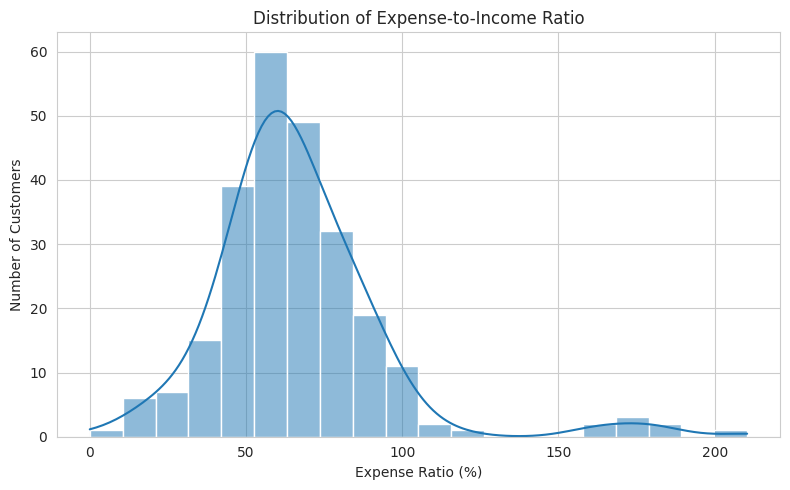

========== OUTLIER ANALYSIS ==========
Lower Bound: 12.26
Upper Bound: 117.48
Number of Outliers: 11


,Customer_ID,Age_Group,Occupation,Monthly_Income,Monthly_Expenses,Savings,Expense_Ratio
169,CUST_040,26-35,Salaried,85100.0,179023.269896,19250.000000,210.368120
95,CUST_160,36-45,Salaried,37500.0,69608.608162,19250.000000,185.622955
170,CUST_223,18-25,Salaried,18000.0,32700.000000,6900.000000,181.666667
157,CUST_250,46-55,Self-employed,18600.0,32700.000000,19250.000000,175.806452
225,CUST_219,36-45,Salaried,64100.0,111195.015272,19250.000000,173.471163
20,CUST_115,36-45,Self-employed,75400.0,126936.031678,19250.000000,168.350175
16,CUST_243,56-65,Salaried,56200.0,90124.142810,19250.000000,160.363243
63,CUST_141,56-65,Self-employed,19200.0,30624.797763,19250.000000,159.504155
75,CUST_127,46-55,Self-employed,49700.0,58400.000000,19250.000000,117.505030
258,CUST_107,26-35,Salaried,56700.0,6062.100729,57188.334742,10.691536



Customers Spending More Than Income: 14


In [10]:
# ==============================
# 4. SEGMENT & OUTLIER ANALYSIS
# ==============================

# --------------------------------
# Visualization 3
# Salaried vs Self-employed
# --------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="Occupation",
    y="Monthly_Expenses"
)

plt.title("Monthly Expenses: Salaried vs Self-employed")
plt.xlabel("Occupation")
plt.ylabel("Monthly Expenses (₹)")
plt.tight_layout()
plt.show()


# --------------------------------
# Visualization 4
# Expense Ratio Distribution
# --------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="Expense_Ratio",
    bins=20,
    kde=True
)

plt.title("Distribution of Expense-to-Income Ratio")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# --------------------------------
# Outlier Detection
# --------------------------------

Q1 = clean_df["Expense_Ratio"].quantile(0.25)
Q3 = clean_df["Expense_Ratio"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["Expense_Ratio"] < lower_bound) |
    (clean_df["Expense_Ratio"] > upper_bound)
]

print("========== OUTLIER ANALYSIS ==========")

print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of Outliers:", len(outliers))

display(
    outliers[
        [
            "Customer_ID",
            "Age_Group",
            "Occupation",
            "Monthly_Income",
            "Monthly_Expenses",
            "Savings",
            "Expense_Ratio"
        ]
    ].sort_values(
        "Expense_Ratio",
        ascending=False
    )
)

# Customers spending more than income
high_spenders = clean_df[
    clean_df["Monthly_Expenses"] >
    clean_df["Monthly_Income"]
]

print(
    "\nCustomers Spending More Than Income:",
    len(high_spenders)
)

In [11]:
# ==============================
# 5. LINEAR REGRESSION
# ==============================

# Target: Monthly Expenses
X = clean_df[["Monthly_Income"]]
y = clean_df["Monthly_Expenses"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== LINEAR REGRESSION ==========")

print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: ₹{model.intercept_:,.2f}")

print(
    f"\nRegression Equation:\n"
    f"Expenses = {model.intercept_:.2f} + "
    f"({model.coef_[0]:.4f} × Income)"
)

print("\n========== MODEL EVALUATION ==========")
print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# Actual vs predicted
results = pd.DataFrame({
    "Actual Expenses": y_test.values,
    "Predicted Expenses": y_pred
})

display(results.head(10))

========== LINEAR REGRESSION ==========
Coefficient: 0.6050
Intercept: ₹3,507.60

Regression Equation:
Expenses = 3507.60 + (0.6050 × Income)

========== MODEL EVALUATION ==========
MAE  : ₹9,548.06
MSE  : 194,550,465.53
RMSE : ₹13,948.13
R²   : 0.3786


,Actual Expenses,Predicted Expenses
0,30800.0,37449.612809
1,20500.0,31157.333219
2,44600.0,45496.470360
3,31500.0,45375.464984
4,16300.0,18391.265975
5,39800.0,37752.126250
6,36000.0,45677.978426
7,85900.0,64191.801064
8,25100.0,32427.889675
9,36800.0,40414.244538


In [12]:
# ==============================
# 6. FINAL INSIGHTS & CONCLUSION
# ==============================

avg_income = clean_df["Monthly_Income"].mean()
avg_expenses = clean_df["Monthly_Expenses"].mean()
avg_savings = clean_df["Savings"].mean()
avg_savings_ratio = clean_df["Savings_Ratio"].mean()
avg_expense_ratio = clean_df["Expense_Ratio"].mean()

# Occupation comparison
occupation_expenses = clean_df.groupby(
    "Occupation"
)["Monthly_Expenses"].mean()

occupation_savings = clean_df.groupby(
    "Occupation"
)["Savings_Ratio"].mean()

print("=" * 60)
print("FINAL DATA SCIENCE RESULTS")
print("=" * 60)

print(f"\nAverage Monthly Income    : ₹{avg_income:,.2f}")
print(f"Average Monthly Expenses  : ₹{avg_expenses:,.2f}")
print(f"Average Monthly Savings   : ₹{avg_savings:,.2f}")
print(f"Average Savings Ratio     : {avg_savings_ratio:.2f}%")
print(f"Average Expense Ratio     : {avg_expense_ratio:.2f}%")

print(
    f"\nIncome-Expense Correlation: "
    f"{correlation:.3f}"
)

print(
    f"Unusual Customers         : "
    f"{len(outliers)}"
)

print(
    f"Spending > Income         : "
    f"{len(high_spenders)} customers"
)

print(f"\nLinear Regression R²      : {r2:.4f}")
print(f"Linear Regression RMSE    : ₹{rmse:,.2f}")

print("\n========== OCCUPATION COMPARISON ==========")

for occupation in occupation_expenses.index:
    print(
        f"{occupation}: "
        f"Average Expenses = ₹{occupation_expenses[occupation]:,.2f}, "
        f"Average Savings Ratio = "
        f"{occupation_savings[occupation]:.2f}%"
    )

print("\n========== CONCLUSION ==========")

if correlation >= 0.7:
    print(
        "The dataset shows a strong positive association between "
        "income and expenditure. Higher-income customers tend "
        "to have higher expenses."
    )
elif correlation >= 0.4:
    print(
        "The dataset shows a moderate positive association between "
        "income and expenditure. Income is related to spending, "
        "but it does not completely explain spending behavior."
    )
else:
    print(
        "The dataset shows a weak linear association between "
        "income and expenditure. Income alone does not appear "
        "to be a strong predictor of spending."
    )

print(
    "\nBusiness implication: Income should be considered together "
    "with spending ratios, savings behavior, credit-card spending, "
    "occupation and loan exposure rather than being used as the "
    "only indicator of customer spending behavior."
)

FINAL DATA SCIENCE RESULTS

Average Monthly Income    : ₹54,638.40
Average Monthly Expenses  : ₹35,682.05
Average Monthly Savings   : ₹22,193.17
Average Savings Ratio     : 42.18%
Average Expense Ratio     : 66.20%

Income-Expense Correlation: 0.637
Unusual Customers         : 11
Spending > Income         : 14 customers

Linear Regression R²      : 0.3786
Linear Regression RMSE    : ₹13,948.13

========== OCCUPATION COMPARISON ==========
Salaried: Average Expenses = ₹35,265.34, Average Savings Ratio = 41.29%
Self-employed: Average Expenses = ₹36,462.77, Average Savings Ratio = 43.83%

========== CONCLUSION ==========
The dataset shows a moderate positive association between income and expenditure. Income is related to spending, but it does not completely explain spending behavior.

Business implication: Income should be considered together with spending ratios, savings behavior, credit-card spending, occupation and loan exposure rather than being used as the only indicator of customer 

# Day - 01 - Q11

In [13]:
# ==========================================
# 1. LOAD AND INSPECT DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
print("Duplicate Employee IDs:",
      df["Employee_ID"].duplicated().sum())

print("\nDesignation Values:")
print(df["Designation"].value_counts(dropna=False))

print("\nEducation Values:")
print(df["Education"].value_counts(dropna=False))

print("\nLocation Values:")
print(df["Location"].value_counts(dropna=False))

print("\nNumerical Summary:")
display(df.describe())

Saving DS_Day01_11_HR_Salary_Inconsistent_Dataset.csv to DS_Day01_11_HR_Salary_Inconsistent_Dataset.csv
Dataset Shape: (270, 8)

First 5 Records:


,Employee_ID,Designation,Experience,Education,Location,Performance_Score,Salary,Salary_Increment
0,EMP_031,Tech Lead,9,PhD,Chennai,1.0,2113000.0,3.4
1,EMP_117,Data Analyst,1,Bachelor's,Hyderabad,3.0,564000.0,3.7
2,EMP_080,Junior Developer,0,Bachelor's,Hyderabad,4.0,947000.0,6.5
3,EMP_128,Data Analyst,0,Bachelor's,Hyderabad,4.0,774000.0,7.9
4,EMP_197,Project Manager,6,Bachelor's,Bangalore,5.0,2111000.0,8.6



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        270 non-null    object 
 1   Designation        265 non-null    object 
 2   Experience         270 non-null    int64  
 3   Education          266 non-null    object 
 4   Location           266 non-null    object 
 5   Performance_Score  265 non-null    float64
 6   Salary             265 non-null    float64
 7   Salary_Increment   270 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 17.0+ KB

Missing Values:
Employee_ID          0
Designation          5
Experience           0
Education            4
Location             4
Performance_Score    5
Salary               5
Salary_Increment     0
dtype: int64

Duplicate Rows: 10
Duplicate Employee IDs: 10

Designation Values:
Designation
Software Engineer             70
Juni

,Experience,Performance_Score,Salary,Salary_Increment
count,270.000000,265.000000,2.650000e+02,270.000000
mean,4.588889,3.301887,1.201879e+06,6.650000
std,4.978529,1.239882,6.662577e+05,2.852792
min,-2.000000,0.000000,-3.000000e+05,-3.000000
25%,1.000000,3.000000,7.280000e+05,5.000000
50%,3.000000,3.000000,9.680000e+05,6.750000
75%,6.000000,4.000000,1.692000e+06,8.500000
max,45.000000,7.000000,3.148000e+06,25.000000


In [14]:
# ==========================================
# 2. DATA CLEANING AND VALIDATION
# ==========================================

clean_df = df.copy()

# Remove duplicate employees
clean_df = clean_df.drop_duplicates(
    subset="Employee_ID",
    keep="first"
)

# ---------- Designation ----------
clean_df["Designation"] = (
    clean_df["Designation"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["Designation"] = clean_df["Designation"].replace({
    "software engineer": "Software Engineer",
    "senior software engineer": "Senior Software Engineer",
    "junior developer": "Junior Developer",
    "tech lead": "Tech Lead",
    "project manager": "Project Manager",
    "data analyst": "Data Analyst",
    "hr executive": "HR Executive",
    "intern": "Junior Developer",
    "unknown": np.nan
})

# ---------- Education ----------
clean_df["Education"] = (
    clean_df["Education"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["Education"] = clean_df["Education"].replace({
    "bachelors": "Bachelor's",
    "bachelor's": "Bachelor's",
    "master's": "Master's",
    "mba": "MBA",
    "phd": "PhD",
    "diploma": np.nan,
    "unknown": np.nan
})

# ---------- Location ----------
clean_df["Location"] = (
    clean_df["Location"]
    .astype("string")
    .str.strip()
    .str.title()
)

clean_df["Location"] = clean_df["Location"].replace({
    "Remote": np.nan,
    "Unknown": np.nan
})

# ---------- Numeric columns ----------
numeric_cols = [
    "Experience",
    "Performance_Score",
    "Salary",
    "Salary_Increment"
]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )

# Invalid values
clean_df.loc[
    (clean_df["Experience"] < 0) |
    (clean_df["Experience"] > 40),
    "Experience"
] = np.nan

clean_df.loc[
    ~clean_df["Performance_Score"].between(1, 5),
    "Performance_Score"
] = np.nan

clean_df.loc[
    clean_df["Salary"] <= 0,
    "Salary"
] = np.nan

clean_df.loc[
    ~clean_df["Salary_Increment"].between(0, 20),
    "Salary_Increment"
] = np.nan

# Fill missing categorical values
for col in ["Designation", "Education", "Location"]:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].mode()[0]
    )

# Fill numerical values with median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )

print("Cleaned Shape:", clean_df.shape)

print("\nRemaining Missing Values:")
print(clean_df.isnull().sum())

print("\nDuplicate Employee IDs:",
      clean_df["Employee_ID"].duplicated().sum())

display(clean_df.head())

Cleaned Shape: (260, 8)

Remaining Missing Values:
Employee_ID          0
Designation          0
Experience           0
Education            0
Location             0
Performance_Score    0
Salary               0
Salary_Increment     0
dtype: int64

Duplicate Employee IDs: 0


,Employee_ID,Designation,Experience,Education,Location,Performance_Score,Salary,Salary_Increment
0,EMP_031,Tech Lead,9.0,PhD,Chennai,1.0,2113000.0,3.4
1,EMP_117,Data Analyst,1.0,Bachelor's,Hyderabad,3.0,564000.0,3.7
2,EMP_080,Junior Developer,0.0,Bachelor's,Hyderabad,4.0,947000.0,6.5
3,EMP_128,Data Analyst,0.0,Bachelor's,Hyderabad,4.0,774000.0,7.9
4,EMP_197,Project Manager,6.0,Bachelor's,Bangalore,5.0,2111000.0,8.6


========== DESCRIPTIVE STATISTICS ==========


,count,mean,std,min,25%,50%,75%,max
Experience,260.0,4.469231e+00,4.264767,0.0,1.000,3.00,6.000,17.0
Performance_Score,260.0,3.303846e+00,1.187119,1.0,3.000,3.00,4.000,5.0
Salary,260.0,1.209785e+06,647946.295079,284000.0,745500.000,971000.00,1691250.000,3148000.0
Salary_Increment,260.0,6.636538e+00,2.562273,0.0,5.075,6.75,8.425,12.0



========== DESIGNATION SUMMARY ==========


Salary            Experience         \
                                  mean     median       mean median   
Designation                                                           
Data Analyst              8.146190e+05   774000.0   0.619048    0.0   
HR Executive              6.780294e+05   662500.0   1.176471    1.5   
Junior Developer          6.588864e+05   614000.0   1.159091    1.0   
Project Manager           1.753478e+06  1744000.0   4.782609    5.0   
Senior Software Engineer  1.652778e+06  1699000.0   8.444444    9.0   
Software Engineer         1.034360e+06  1009000.0   3.880000    3.0   
Tech Lead                 2.518000e+06  2511000.0  13.074074   12.0   

                         Salary_Increment         
                                     mean median  
Designation                                       
Data Analyst                     7.497619    7.4  
HR Executive                     6.929412    7.2  
Junior Developer                 6.822727    7.0  
Project Manager                  6.869565    7.1  
Senior Software Engineer         5.580556    5.3  
Software Engineer                6.899333    6.9  
Tech Lead                        5.774074    6.3

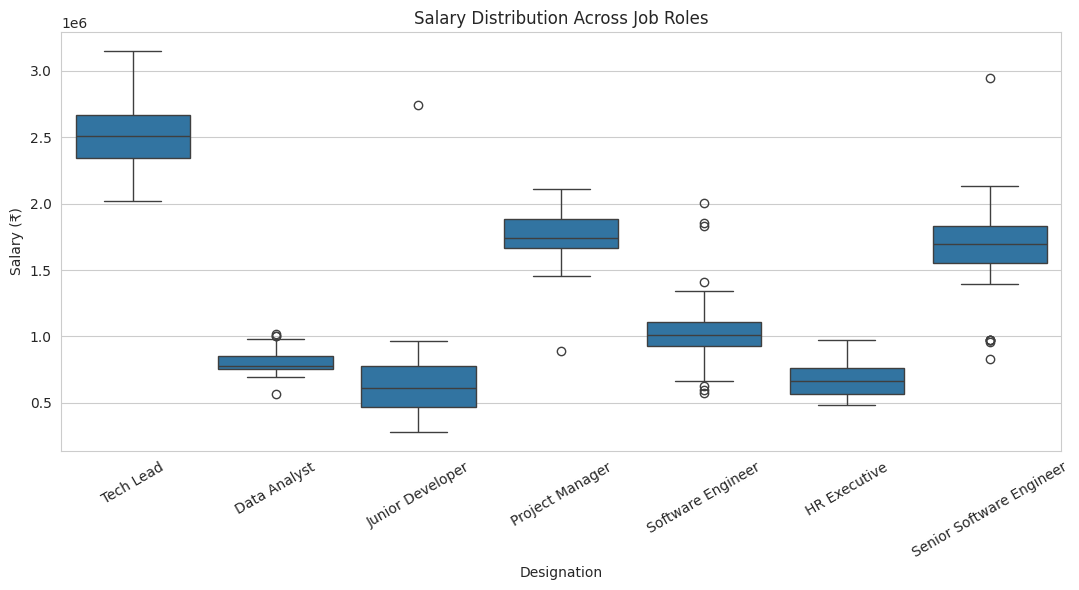

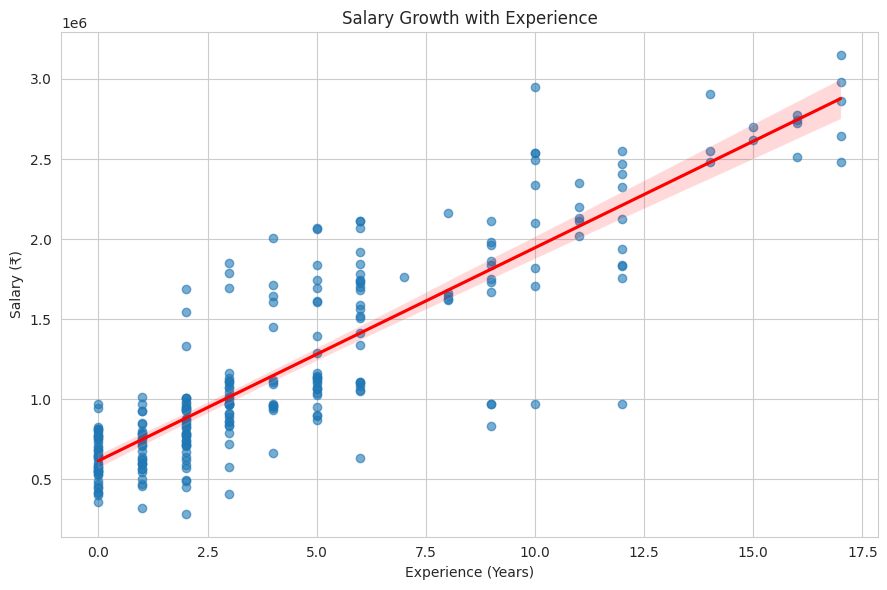


Experience-Salary Correlation: 0.876


In [15]:
# ==========================================
# 3. SALARY EDA
# ==========================================

print("========== DESCRIPTIVE STATISTICS ==========")
display(clean_df.describe().T)

# ------------------------------------------
# Salary by Designation
# ------------------------------------------

designation_summary = clean_df.groupby(
    "Designation"
)[
    ["Salary", "Experience", "Salary_Increment"]
].agg(["mean", "median"])

print("\n========== DESIGNATION SUMMARY ==========")
display(designation_summary)

# ==========================================
# VISUALIZATION 1
# Salary by Designation
# ==========================================

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=clean_df,
    x="Designation",
    y="Salary"
)

plt.title("Salary Distribution Across Job Roles")
plt.xlabel("Designation")
plt.ylabel("Salary (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ==========================================
# VISUALIZATION 2
# Salary vs Experience
# ==========================================

plt.figure(figsize=(9, 6))

sns.regplot(
    data=clean_df,
    x="Experience",
    y="Salary",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Salary Growth with Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (₹)")

plt.tight_layout()
plt.show()

# Correlation
salary_experience_corr = clean_df[
    "Experience"
].corr(
    clean_df["Salary"]
)

print(
    "\nExperience-Salary Correlation:",
    round(salary_experience_corr, 3)
)

========== LOCATION SUMMARY ==========


,Salary,Salary_Increment,Performance_Score
Location,,,
Bangalore,1.373603e+06,6.832353,3.367647
Delhi,1.346696e+06,5.765217,2.869565
Mumbai,1.309810e+06,5.959524,3.142857
Pune,1.110030e+06,6.695455,3.303030
Chennai,1.067550e+06,7.027500,3.425000
Hyderabad,1.033704e+06,6.962037,3.444444


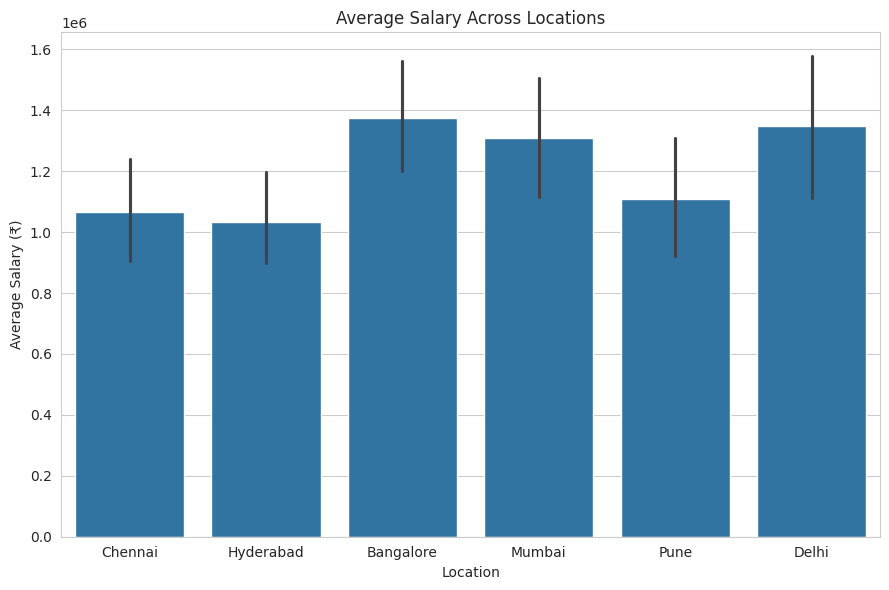


========== PERFORMANCE / INCREMENT ==========


,Salary_Increment
Performance_Score,
1.0,2.091667
2.0,4.431081
3.0,6.229012
4.0,7.756944
5.0,9.745652


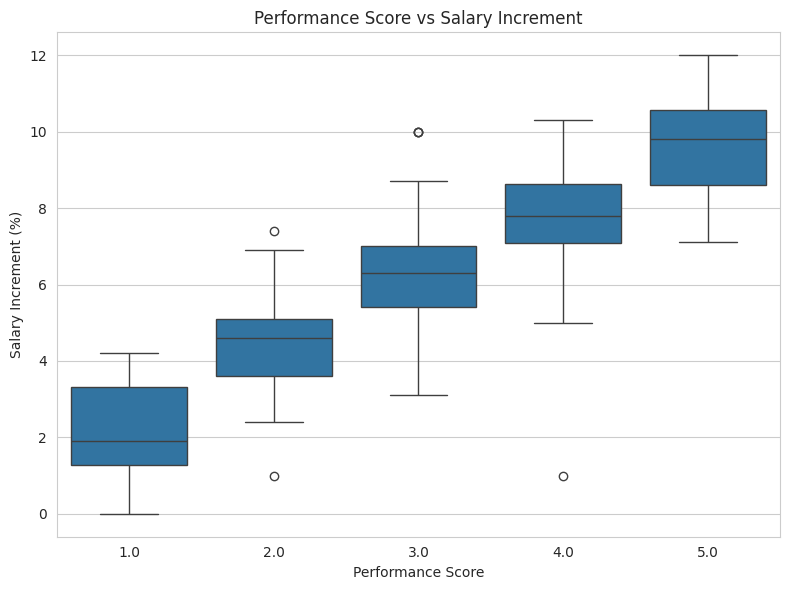


Performance-Increment Correlation: 0.846


In [16]:
# ==========================================
# 4. LOCATION & PERFORMANCE ANALYSIS
# ==========================================

# ------------------------------------------
# Location salary comparison
# ------------------------------------------

location_summary = clean_df.groupby(
    "Location"
)[
    ["Salary", "Salary_Increment", "Performance_Score"]
].mean().sort_values(
    "Salary",
    ascending=False
)

print("========== LOCATION SUMMARY ==========")
display(location_summary)


# ==========================================
# VISUALIZATION 3
# Salary Across Locations
# ==========================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=clean_df,
    x="Location",
    y="Salary"
)

plt.title("Average Salary Across Locations")
plt.xlabel("Location")
plt.ylabel("Average Salary (₹)")

plt.tight_layout()
plt.show()


# ==========================================
# Performance vs Salary Increment
# ==========================================

performance_summary = clean_df.groupby(
    "Performance_Score"
)["Salary_Increment"].mean()

print("\n========== PERFORMANCE / INCREMENT ==========")
display(performance_summary)


# ==========================================
# VISUALIZATION 4
# Performance vs Salary Increment
# ==========================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=clean_df,
    x="Performance_Score",
    y="Salary_Increment"
)

plt.title("Performance Score vs Salary Increment")
plt.xlabel("Performance Score")
plt.ylabel("Salary Increment (%)")

plt.tight_layout()
plt.show()

performance_increment_corr = clean_df[
    "Performance_Score"
].corr(
    clean_df["Salary_Increment"]
)

print(
    "\nPerformance-Increment Correlation:",
    round(performance_increment_corr, 3)
)

In [17]:
# ==========================================
# 5. COMPENSATION FAIRNESS + ML MODEL
# ==========================================

# ------------------------------------------
# Encode categorical variables
# ------------------------------------------

model_df = pd.get_dummies(
    clean_df[
        [
            "Designation",
            "Experience",
            "Education",
            "Location",
            "Performance_Score",
            "Salary"
        ]
    ],
    drop_first=True
)

X = model_df.drop(
    "Salary",
    axis=1
)

y = model_df["Salary"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------
# Linear Regression
# ------------------------------------------

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

# ------------------------------------------
# Evaluation
# ------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== LINEAR REGRESSION ==========")

print("Target: Salary")

print(
    "\nMAE  : ₹",
    round(mae, 2)
)

print(
    "MSE  :",
    round(mse, 2)
)

print(
    "RMSE : ₹",
    round(rmse, 2)
)

print(
    "R²   :",
    round(r2, 4)
)

# ------------------------------------------
# Predict salary for ALL employees
# ------------------------------------------

clean_model_df = pd.get_dummies(
    clean_df[
        [
            "Designation",
            "Experience",
            "Education",
            "Location",
            "Performance_Score"
        ]
    ],
    drop_first=True
)

# Ensure same columns as training data
clean_model_df = clean_model_df.reindex(
    columns=X.columns,
    fill_value=0
)

predicted_salary = model.predict(
    clean_model_df
)

clean_df["Expected_Salary"] = predicted_salary

clean_df["Salary_Residual"] = (
    clean_df["Salary"] -
    clean_df["Expected_Salary"]
)

# Percentage difference
clean_df["Salary_Difference_Percent"] = (
    clean_df["Salary_Residual"] /
    clean_df["Expected_Salary"]
) * 100

# Employees significantly below/above model expectation
compensation_outliers = clean_df[
    clean_df["Salary_Difference_Percent"].abs() >= 20
].sort_values(
    "Salary_Difference_Percent"
)

print("\n========== COMPENSATION ANOMALIES ==========")

print(
    "Employees with salary difference >= 20%:",
    len(compensation_outliers)
)

display(
    compensation_outliers[
        [
            "Employee_ID",
            "Designation",
            "Experience",
            "Education",
            "Location",
            "Performance_Score",
            "Salary",
            "Expected_Salary",
            "Salary_Difference_Percent"
        ]
    ].head(20)
)

========== LINEAR REGRESSION ==========
Target: Salary

MAE  : ₹ 129752.38
MSE  : 54525005305.32
RMSE : ₹ 233505.9
R²   : 0.8909

========== COMPENSATION ANOMALIES ==========
Employees with salary difference >= 20%: 32


,Employee_ID,Designation,Experience,Education,Location,Performance_Score,Salary,Expected_Salary,Salary_Difference_Percent
11,EMP_025,Senior Software Engineer,9.0,Bachelor's,Bangalore,3.0,831000.0,1.738156e+06,-52.190716
31,EMP_069,Junior Developer,2.0,Bachelor's,Chennai,3.0,284000.0,5.908654e+05,-51.934908
193,EMP_146,Junior Developer,3.0,Bachelor's,Mumbai,3.0,405000.0,8.062389e+05,-49.766750
84,EMP_202,Junior Developer,1.0,MBA,Chennai,4.0,323000.0,6.343248e+05,-49.079711
138,EMP_137,Senior Software Engineer,12.0,Bachelor's,Bangalore,1.0,971000.0,1.876000e+06,-48.240945
125,EMP_173,Senior Software Engineer,9.0,Master's,Hyderabad,5.0,971000.0,1.815230e+06,-46.508166
202,EMP_104,Senior Software Engineer,10.0,Master's,Chennai,3.0,971000.0,1.763557e+06,-44.940827
227,EMP_255,Software Engineer,4.0,Master's,Bangalore,3.0,662000.0,1.107608e+06,-40.231575
61,EMP_076,Project Manager,3.0,Bachelor's,Hyderabad,3.0,891000.0,1.487353e+06,-40.094918
150,EMP_062,Software Engineer,6.0,Bachelor's,Pune,2.0,630000.0,1.051118e+06,-40.063821


In [18]:
# ==========================================
# 6. FINAL RESULTS & ACTION PLAN
# ==========================================

avg_salary = clean_df["Salary"].mean()
avg_experience = clean_df["Experience"].mean()
avg_increment = clean_df["Salary_Increment"].mean()

highest_role = (
    clean_df.groupby("Designation")["Salary"]
    .mean()
    .idxmax()
)

lowest_role = (
    clean_df.groupby("Designation")["Salary"]
    .mean()
    .idxmin()
)

highest_location = (
    clean_df.groupby("Location")["Salary"]
    .mean()
    .idxmax()
)

highest_increment_performance = (
    clean_df.groupby("Performance_Score")["Salary_Increment"]
    .mean()
    .idxmax()
)

print("=" * 65)
print("FINAL HR COMPENSATION ANALYSIS")
print("=" * 65)

print(f"\nAverage Salary: ₹{avg_salary:,.2f}")
print(f"Average Experience: {avg_experience:.2f} years")
print(f"Average Salary Increment: {avg_increment:.2f}%")

print(
    f"\nSalary-Experience Correlation: "
    f"{salary_experience_corr:.3f}"
)

print(
    f"Performance-Increment Correlation: "
    f"{performance_increment_corr:.3f}"
)

print(
    f"\nHighest Average-Paid Role: {highest_role}"
)

print(
    f"Lowest Average-Paid Role: {lowest_role}"
)

print(
    f"Highest Average-Paid Location: {highest_location}"
)

print(
    f"Performance Score with Highest Average Increment: "
    f"{highest_increment_performance}"
)

print(
    f"\nCompensation Anomalies: "
    f"{len(compensation_outliers)} employees"
)

print(
    f"\nLinear Regression R²: {r2:.4f}"
)

print(
    f"Linear Regression RMSE: ₹{rmse:,.2f}"
)


# ------------------------------------------
# KEY INSIGHTS
# ------------------------------------------

print("\n" + "=" * 65)
print("KEY INSIGHTS")
print("=" * 65)

print(f"""
1. Salary varies across designations, indicating that job role
   is an important component of compensation structure.

2. Experience has a correlation of {salary_experience_corr:.3f}
   with salary in the cleaned dataset.

3. The location analysis shows differences in average salary
   between geographic markets.

4. Performance score and salary increment have a correlation
   of {performance_increment_corr:.3f}.

5. {len(compensation_outliers)} employees have salaries that differ
   by at least 20% from the salary expected by the regression
   model based on their observed profile.

6. Compensation differences cannot automatically be interpreted
   as unfairness because factors such as role, experience,
   education, location and performance contribute to salary.

7. The Linear Regression model achieved an R² of {r2:.4f},
   providing a quantitative measure of how well the selected
   employee attributes explain salary variation.
""")


# ------------------------------------------
# PRACTICAL ACTION PLAN
# ------------------------------------------

print("=" * 65)
print("PRACTICAL ACTION PLAN")
print("=" * 65)

print("""
1. Conduct periodic salary-band reviews by designation.

2. Compare employees against peers with similar role,
   experience, education, location and performance.

3. Investigate employees with large positive or negative
   salary residuals rather than automatically labeling them
   as unfairly compensated.

4. Review whether performance scores are consistently reflected
   in salary increments.

5. Maintain location-specific salary benchmarks where local
   labor-market differences justify them.

6. Establish transparent salary ranges for each designation
   and experience level.

7. Use the regression model as an analytical support tool,
   not as the sole mechanism for determining employee pay.
""")

FINAL HR COMPENSATION ANALYSIS

Average Salary: ₹1,209,784.62
Average Experience: 4.47 years
Average Salary Increment: 6.64%

Salary-Experience Correlation: 0.876
Performance-Increment Correlation: 0.846

Highest Average-Paid Role: Tech Lead
Lowest Average-Paid Role: Junior Developer
Highest Average-Paid Location: Bangalore
Performance Score with Highest Average Increment: 5.0

Compensation Anomalies: 32 employees

Linear Regression R²: 0.8909
Linear Regression RMSE: ₹233,505.90

KEY INSIGHTS

1. Salary varies across designations, indicating that job role
   is an important component of compensation structure.

2. Experience has a correlation of 0.876
   with salary in the cleaned dataset.

3. The location analysis shows differences in average salary
   between geographic markets.

4. Performance score and salary increment have a correlation
   of 0.846.

5. 32 employees have salaries that differ
   by at least 20% from the salary expected by the regression
   model based on their obse